In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9649122807017544


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=50)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9649122807017544


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.956140350877193


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.956140350877193


Random Forest Accuracy: 0.9649122807017544
AdaBoost Accuracy: 0.9649122807017544
Gradient Boosting Accuracy: 0.956140350877193
Stacking Accuracy: 0.956140350877193


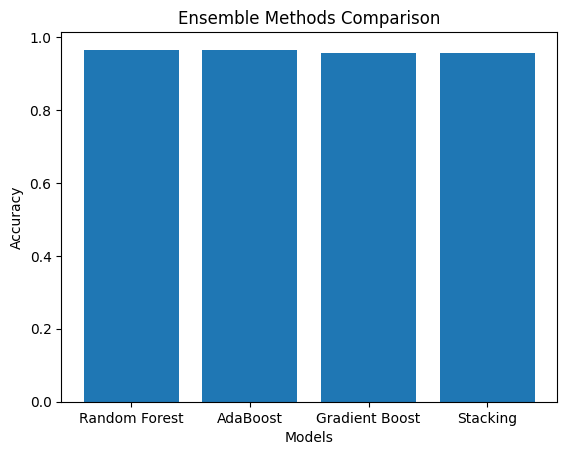

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# -----------------------------
# 2. AdaBoost
adb = AdaBoostClassifier(n_estimators=50)
adb.fit(X_train, y_train)
adb_pred = adb.predict(X_test)
adb_acc = accuracy_score(y_test, adb_pred)

# -----------------------------
# 3. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

# -----------------------------
# 4. Stacking
estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

# -----------------------------
# Print results
print("Random Forest Accuracy:", rf_acc)
print("AdaBoost Accuracy:", adb_acc)
print("Gradient Boosting Accuracy:", gb_acc)
print("Stacking Accuracy:", stack_acc)

# -----------------------------
# Comparison Graph
models = ['Random Forest', 'AdaBoost', 'Gradient Boost', 'Stacking']
accuracies = [rf_acc, adb_acc, gb_acc, stack_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Ensemble Methods Comparison")
plt.show()